In [ ]:
import os
os.chdir("..")
print(os.getcwd())

/Users/jacoboromerodiaz/Projects/video-retrieval-cvpr


In [ ]:
from torchcodec.decoders import VideoDecoder
from pathlib import Path
import os

VID_ROOT = Path("covr/data/covr-r/videos")

def video_stats(n: int = 10, seed: int = 42):
    paths = sorted(VID_ROOT.glob("*"))
    rng = __import__("random").Random(seed)
    sample = rng.sample(paths, min(n, len(paths)))

    rows = []
    for p in sample:
        dec = VideoDecoder(str(p))
        m = dec.metadata
        rows.append({
            "file": p.name,
            "fps": round(m.average_fps, 2) if m.average_fps else None,
            "duration_s": round(m.duration_seconds, 2) if m.duration_seconds else None,
            "num_frames": m.num_frames,
            "width": m.width,
            "height": m.height,
            "codec": m.codec,
            "size_mb": round(os.path.getsize(p) / 1e6, 2),
        })

    header = f"{'file':<30} {'fps':>6} {'dur(s)':>8} {'frames':>7} {'W':>5} {'H':>5} {'codec':<8} {'MB':>6}"
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['file']:<30} {str(r['fps']):>6} {str(r['duration_s']):>8} "
            f"{str(r['num_frames']):>7} {str(r['width']):>5} {str(r['height']):>5} "
            f"{str(r['codec']):<8} {r['size_mb']:>6}"
        )
    return rows

rows = video_stats(n=100)


file                              fps   dur(s)  frames     W     H codec        MB
----------------------------------------------------------------------------------
104974.webm                      12.0     4.17      50   427   240 vp9        0.05
1013218574.mp4                   30.0    17.83     535   596   336 h264       2.19
19108057.mp4                       25       17     425   596   336 h264       1.98
17106304.mp4                       24       27     648   596   336 h264       3.14
157915.webm                        12     3.25      39   427   240 vp9        0.05
11084597.mp4                       25    34.96     874   596   336 h264       4.21
1042784314.mp4                  29.97    40.04    1200   596   336 h264       4.51
1033290905.mp4                     25    11.48     287   596   336 h264        0.6
42587.webm                         12        5      60   360   240 vp9        0.08
1015419451.mp4                  29.97     4.04     121   596   336 h264       0.46
1014

In [ ]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

EMB_ROOT = Path("features/gallery/vjepa_base")

sample_path = next(EMB_ROOT.glob("*.pt"))
emb = torch.load(sample_path, weights_only=True)

print(f"path: {sample_path}")
print(f"shape: {emb.shape}   # [num_patches, hidden_dim]")
print(f"dtype: {emb.dtype}")
print(f"min: {emb.min():.4f}")
print(f"max: {emb.max():.4f}")
print(f"mean: {emb.mean():.4f}")
print(f"std: {emb.std():.4f}")
print(f"norm (mean over patches): {emb.norm(dim=-1).mean():.4f}")
print(f"has nan: {emb.isnan().any().item()}  |  has inf: {emb.isinf().any().item()}")

StopIteration: 

In [ ]:
EMB_ROOT = Path("features/gallery/vjepa_base")

def collect_stats(n: int = 50):
    paths = list(EMB_ROOT.glob("*.pt"))[:n]
    rows = []
    for p in paths:
        t = torch.load(p, weights_only=True)
        if t.isnan().any():
            print(f"NaN en {p}  shape={tuple(t.shape)}")
            continue
        rows.append({
            "id": p.stem,
            "shape": tuple(t.shape),
            "mean_norm": t.norm(dim=-1).mean().item(),
            "global_mean": t.mean().item(),
            "global_std": t.std().item(),
        })
    return rows

stats = collect_stats()
norms = [r["mean_norm"] for r in stats]
shapes = {r["shape"] for r in stats}
print(f"\n[shapes={shapes}  norm: mean={np.mean(norms):.3f}  std={np.std(norms):.3f}")



[ss2]  shapes={(1560, 768), (1620, 768), (1320, 768), (1080, 768), (1200, 768)}  norm: mean=30.529  std=0.259
NaN en video_embeddings/webvid/1154.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1045.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1105.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1131.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1071.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1082.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1092.pt  shape=(3108, 768)
NaN en video_embeddings/webvid/1212.pt  shape=(3108, 768)

[webvid]  shapes={(3108, 768), (2812, 768)}  norm: mean=30.737  std=0.354


In [ ]:
import torch
from covr.data.dataset import find_video, load_frames
from pathlib import Path
from collections import defaultdict

VID_ROOT = Path('covr/data/covr-r/videos')

def study_frames(n=100):
    paths = list(VID_ROOT.glob("*"))[:n]
    records = []
    for path in paths:
        frames = load_frames(path)
        records.append({
            "id": path.stem,
            "shape": tuple(frames.shape),        # (C, T, H, W)
            "has_nan": frames.isnan().any().item(),
            "has_inf": frames.isinf().any().item(),
            "has_constant_patch": (frames.std(dim=1) == 0).any().item(),
        })

    unique_shapes = sorted({r["shape"] for r in records})
    nan_videos = [r["id"] for r in records if r["has_nan"]]
    inf_videos = [r["id"] for r in records if r["has_inf"]]
    constant_videos = [r["id"] for r in records if r["has_constant_patch"]]

    print(f"[{split}]  n={len(records)}")
    print(f"unique shapes (C, T, H, W): {unique_shapes}")
    print(f"has_nan:  {len(nan_videos)}/{len(records)}  ids={nan_videos}")
    print(f"has_inf:  {len(inf_videos)}/{len(records)}  ids={inf_videos}")
    print(f"constant patch: {len(constant_videos)}/{len(records)}  ids={constant_videos}")
    return records

study_frames()

[webvid]  n=100
unique shapes (C, T, H, W): [(3, 8, 240, 320), (3, 8, 240, 360), (3, 8, 240, 400), (3, 8, 240, 424), (3, 8, 240, 427), (3, 8, 240, 432), (3, 8, 316, 600), (3, 8, 336, 504), (3, 8, 336, 592), (3, 8, 336, 596)]
has_nan:  0/100  ids=[]
has_inf:  0/100  ids=[]
constant patch: 73/100  ids=['24748814', '160059', '24601', '1009165157', '1021775830', '17161', '16320325', '8210521', '151641', '15422563', '89496', '1022305480', '1036568594', '27387901', '170235', '150729', '23186836', '1018613518', '34876948', '26145', '11797898', '1007815789', '25769', '165871', '183708', '10703693', '1044204745', '1025920277', '139061', '29121', '25484369', '12621', '1024081139', '65966', '1415692', '31991299', '1028323193', '1019514496', '25791737', '1022033377', '154697', '1048180927', '175430', '52746', '10812344', '169556', '40794', '1026368600', '80875', '2866612', '1063743199', '32098756', '39137', '120505', '1039279331', '34355', '8138611', '79050', '1050867430', '17784820', '47417', '90

[{'id': '24748814',
  'shape': (3, 8, 336, 596),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '160059',
  'shape': (3, 8, 240, 360),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '24601',
  'shape': (3, 8, 240, 427),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '1009165157',
  'shape': (3, 8, 336, 596),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '166924',
  'shape': (3, 8, 240, 320),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': False},
 {'id': '1021775830',
  'shape': (3, 8, 336, 596),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '14221124',
  'shape': (3, 8, 316, 600),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': False},
 {'id': '17161',
  'shape': (3, 8, 240, 427),
  'has_nan': False,
  'has_inf': False,
  'has_constant_patch': True},
 {'id': '16320325',
  'shape': (3, 8, 336, 5

In [ ]:
QEMB_ROOT = Path("features/queries/flan_large")

def collect_stats(n: int = 50):
    paths = list((QEMB_ROOT).glob("*.pt"))[:n]
    rows = []
    for p in paths:
        t = torch.load(p, weights_only=True)
        if t.isnan().any():
            print(f"NaN en {p}  shape={tuple(t.shape)}")
            continue
        rows.append({
            "id": p.stem,
            "shape": tuple(t.shape),
            "mean_norm": t.norm(dim=-1).mean().item(),
            "global_mean": t.mean().item(),
            "global_std": t.std().item(),
        })
    return rows


stats = collect_stats()
norms = [r["mean_norm"] for r in stats]
shapes = {r["shape"] for r in stats}
print(f"\n[{split}]  shapes={shapes}  norm: mean={np.mean(norms):.3f}  std={np.std(norms):.3f}")



[webvid]  shapes={(143, 1024), (163, 1024), (165, 1024), (156, 1024), (189, 1024), (167, 1024), (145, 1024), (147, 1024), (193, 1024), (158, 1024), (149, 1024), (171, 1024), (162, 1024), (142, 1024), (175, 1024), (144, 1024), (166, 1024), (150, 1024), (157, 1024), (168, 1024), (152, 1024), (172, 1024), (141, 1024), (174, 1024)}  norm: mean=1.484  std=0.314


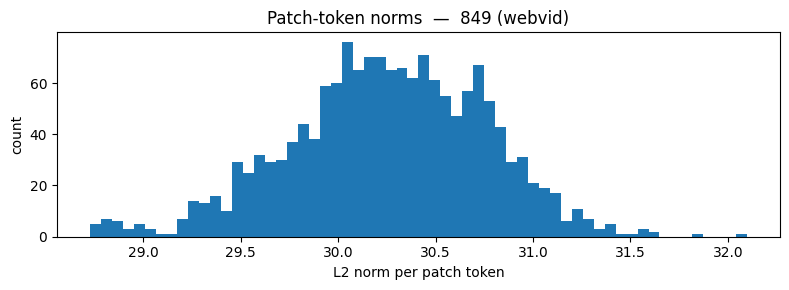

In [ ]:
patch_norms = emb.norm(dim=-1).numpy()

plt.figure(figsize=(8, 3))
plt.hist(patch_norms, bins=60, edgecolor="none")
plt.xlabel("L2 norm per patch token")
plt.ylabel("count")
plt.title(f"Patch-token norms  —  {sample_path.stem} ({split})")
plt.tight_layout()
plt.show()

In [ ]:
paths = list((EMB_ROOT / "ss2").glob("*.pt"))
a = torch.load(paths[0], weights_only=True).mean(0)
b = torch.load(paths[1], weights_only=True).mean(0)
a, b = a / a.norm(), b / b.norm()
print(f"\ncosine sim between {paths[0].stem} and {paths[1].stem}: {(a @ b).item():.4f}")


cosine sim between 849 and 909: 0.9336
